In [76]:
%load_ext autoreload
%autoreload 2
from superbit_lensing.plotter import ClusterRedSequenceAnalysis
import superbit_lensing.utils as utils
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
cluster_name = 'Abell3411'
# datadir = "/scratch/sa.saha/data" #Change to your data directory!
datadir = "/Users/leilaohashi/superbit-lensing/data"
#datafilename = "home/filename.fits"
utils.TARGET_LIST = os.path.join(datadir, "SuperBIT_target_list.csv")
analyzer = ClusterRedSequenceAnalysis(cluster_name, datadir=datadir, delz=0.02)
analyzer.load_data()

Galaxies with z > 0.19: 55
Galaxies with 0.15 < z ≤ 0.19: 171
Galaxies with z ≤ 0.15: 1


Number of objects in the red sequence: 1102


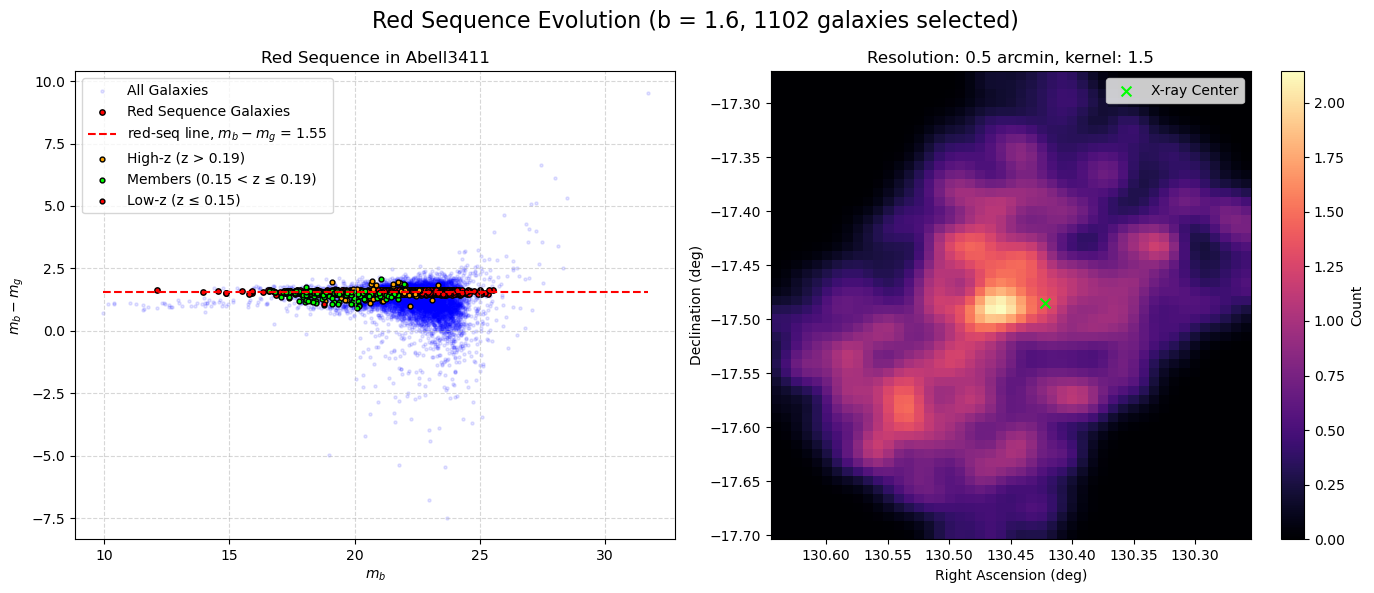

In [23]:
analyzer.compute_red_sequence(a=0.0, b=1.55, tolerance=0.1, resolution=0.5, sigma=1.5, save_path = "")

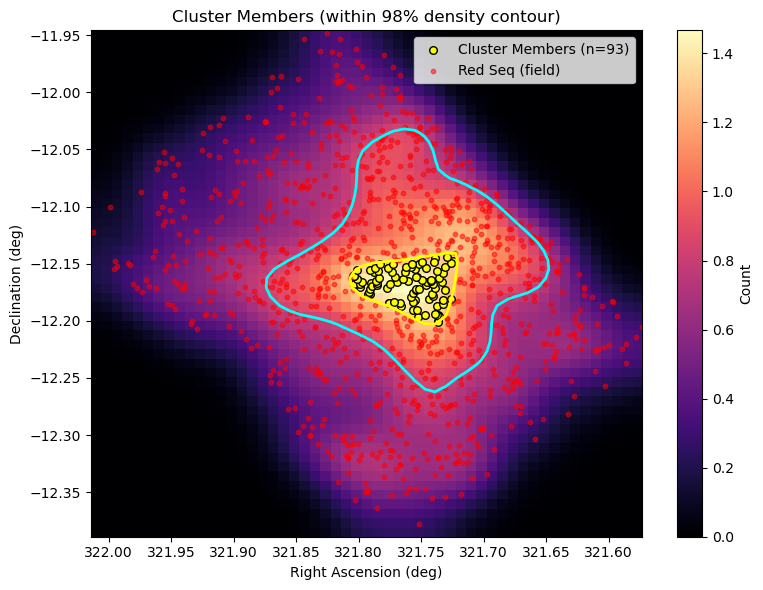


Cluster Member Selection Summary:
Total red sequence galaxies: 1058
Galaxies within cluster contour: 93
Fraction in cluster: 8.8%


In [ ]:
cluster_catalog = analyzer.identify_cluster_members(percentiles=[85, 98], sigma_smooth=2.5)

In [ ]:
# analyzer.save_cluster_catalog()
# analyzer.update_original_catalog()

Saved cluster member catalog to: /scratch/sa.saha/data/Abell2345/sextractor_dualmode/out/Abell2345_coadd_redseq.fits
Total cluster members saved: 93
Updated original catalog: /scratch/sa.saha/data/Abell2345/sextractor_dualmode/out/Abell2345_colors_mags.fits
Total red sequence galaxies marked: 1058
Total cluster members marked: 93


In [ ]:
save_path = f"/Users/leilaohashi/superbit-lensing/notebooks/leila/{cluster_name}"
_ = analyzer._make_rgb_image(red_boost_factor=1.1, green_supression=0.9, blue_suppression=0.9, dpi=1200, save_path=save_path, mark_members=True)

Creating RGB image using:
  U band: /Users/leilaohashi/superbit-lensing/data/Abell3411/sextractor_dualmode/coadd/u/Abell3411_coadd_u.fits
  B band: /Users/leilaohashi/superbit-lensing/data/Abell3411/sextractor_dualmode/coadd/b/Abell3411_coadd_b.fits
  G band: /Users/leilaohashi/superbit-lensing/data/Abell3411/sextractor_dualmode/coadd/g/Abell3411_coadd_g.fits


AttributeError: 'ClusterRedSequenceAnalysis' object has no attribute 'cluster_catalog'

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


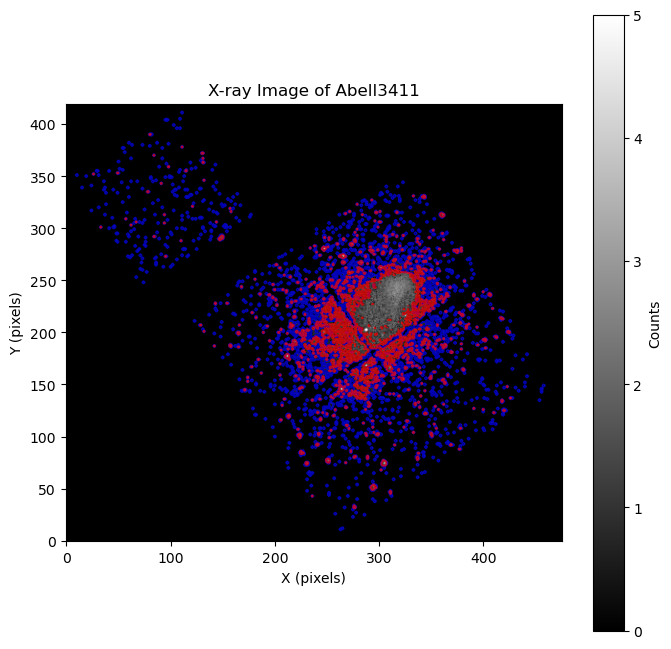

X-ray image saved to /Users/leilaohashi/superbit-lensing/notebooks/leila/Abell3411/Abell3411_xray_image.png


In [ ]:

import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter

cluster_name = "Abell3411"

fits_path = f"/Users/leilaohashi/superbit-lensing/data/xray/{cluster_name}_xray_image.fits"
if not os.path.exists(fits_path):
    print(f"X-ray image for {cluster_name} not found at {fits_path}.")

# Open the image
xray_hdu = fits.open(fits_path)[0]
xray_data = xray_hdu.data
xray_data = np.array(xray_data)
print(xray_data)

# Plot the image
smoothed_counts = gaussian_filter(xray_data, sigma=0.5)
vmin, vmax = np.percentile(xray_data, [1, 99])
plt.figure(figsize=(8, 8))
plt.imshow(np.log1p(smoothed_counts), origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(label='Counts')
plt.title(f'X-ray Image of {cluster_name}')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Contours
contour_levels = np.percentile(smoothed_counts, [1, 95])
plt.contour(smoothed_counts, levels=contour_levels, colors=['blue', 'red'], alpha=0.7)

# Save and show the image
save_path = f"/Users/leilaohashi/superbit-lensing/notebooks/leila/{cluster_name}/{cluster_name}_xray_image.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()

print(f"X-ray image saved to {save_path}")

In [45]:
from astropy.io import fits
fits_path = "/Users/leilaohashi/superbit-lensing/data/xray/Abell3411_xray_image.fits"
hdul = fits.open(fits_path)
hdul.info()

Filename: /Users/leilaohashi/superbit-lensing/data/xray/Abell3411_xray_image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     935   (476, 420)   int32   
  1  GTI           3 BinTableHDU     28   5R x 2C   [1D, 1D]   
  2  GTI           2 BinTableHDU     28   2R x 2C   [1D, 1D]   
  3  GTI           1 BinTableHDU     28   3R x 2C   [1D, 1D]   
  4  GTI           0 BinTableHDU     28   1R x 2C   [1D, 1D]   
  5  GTI           6 BinTableHDU     28   2R x 2C   [1D, 1D]   


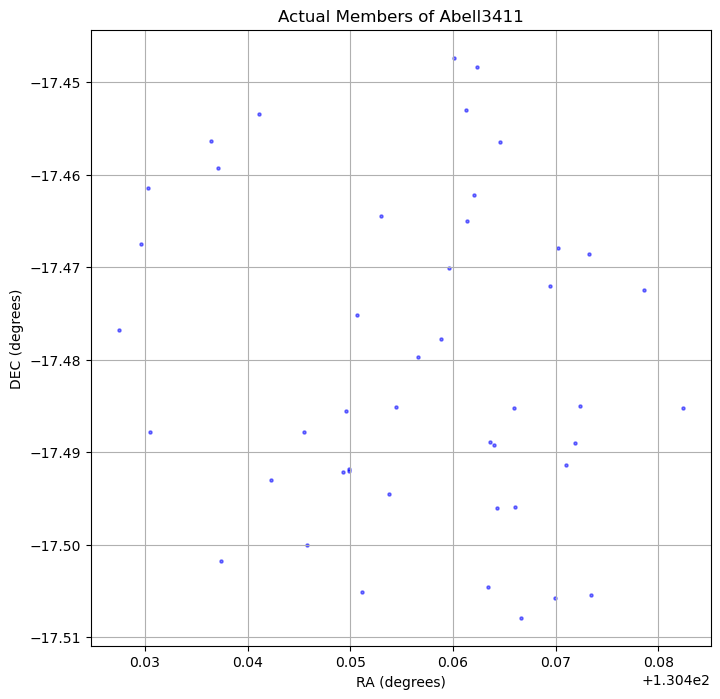

Actual members plot saved to /Users/leilaohashi/superbit-lensing/notebooks/leila/Abell3411/Abell3411_actual_members.png


In [71]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

am_path = f"/Users/leilaohashi/superbit-lensing/data/actual_members/{cluster_name}_actual_members_catalog.fits"
if not os.path.exists(am_path):
    print(f"Actual members file for {cluster_name} not found at {am_path}.")

# Open the image
actual_members_hdu = fits.open(am_path)[1]
actual_members_data = actual_members_hdu.data

# Plot the image
plt.figure(figsize=(8, 8))
plt.scatter(actual_members_data['RA'], actual_members_data['DEC'], s=5, color='blue', alpha=0.5)
plt.title(f'Actual Members of {cluster_name}')
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.grid(True)
# Save and show the image
save_path = f"/Users/leilaohashi/superbit-lensing/notebooks/leila/{cluster_name}/{cluster_name}_actual_members.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Actual members plot saved to {save_path}")


In [69]:
from astropy.io import fits
am_path = "/Users/leilaohashi/superbit-lensing/data/actual_members/Abell3411_actual_members_catalog.fits"
hdul = fits.open(am_path)
hdul.info()

Filename: /Users/leilaohashi/superbit-lensing/data/actual_members/Abell3411_actual_members_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    178   46R x 53C   [J, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, 2601E, 2601E, 2601E, E, E, E, E, E, E, E, E, D, D, D, D, D, K, 7A, 6A, 3A, 6A, D, D, D, D, K, I, L, D, D, 10A, E]   
